In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

warnings.filterwarnings("ignore")

# 1. Loading the metadata
path = "/content/drive/MyDrive/ML_project/metadata.csv"

try:
    df = pd.read_csv(path)
    df = df.drop_duplicates(keep='first')
    print("Dataframe loaded. Shape:", df.shape)
except:
    print("Check if metadata.csv is in the folder")

# 2. Basic Inspection
df.head()

Dataframe loaded. Shape: (2298, 26)


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,FALSE,TRUE,TRUE,PAT_684_1302_588.png,True


In [ ]:
# Statistical summary of numerical features
df.describe()

,lesion_id,age,fitspatrick,diameter_1,diameter_2
count,2298.000000,2298.000000,1494.000000,1494.000000,1494.000000
mean,1529.933856,60.464752,2.265730,11.897055,8.852209
std,1196.285644,15.894866,0.729029,8.634492,5.797036
min,6.000000,6.000000,1.000000,0.000000,0.000000
25%,720.500000,52.000000,2.000000,7.000000,5.000000
50%,1297.000000,62.000000,2.000000,10.000000,8.000000
75%,1782.750000,72.000000,3.000000,15.000000,10.000000
max,4820.000000,94.000000,6.000000,100.000000,70.000000


In [ ]:
# Check types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2298 entries, 0 to 2297
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           2298 non-null   object 
 1   lesion_id            2298 non-null   int64  
 2   smoke                1494 non-null   object 
 3   drink                1494 non-null   object 
 4   background_father    1480 non-null   object 
 5   background_mother    1476 non-null   object 
 6   age                  2298 non-null   int64  
 7   pesticide            1494 non-null   object 
 8   gender               1494 non-null   object 
 9   skin_cancer_history  1494 non-null   object 
 10  cancer_history       1494 non-null   object 
 11  has_piped_water      1494 non-null   object 
 12  has_sewage_system    1494 non-null   object 
 13  fitspatrick          1494 non-null   float64
 14  region               2298 non-null   object 
 15  diameter_1           1494 non-null   f

In [ ]:
def unique_value(df):
    print("Unique values in dataframe")
    features = df.columns
    for feature in features:
        values = df[feature].unique()
        print(feature + ":", end=" ")
        for i in range(len(values) - 1):
            print(values[i], end="; ")
        print(values[-1])
        print()

unique_value(df)

Unique values in dataframe
patient_id: PAT_1516; PAT_46; PAT_1545; PAT_1989; PAT_684; PAT_1549; PAT_778; PAT_117; PAT_1995; PAT_705; PAT_2140; PAT_967; PAT_2088; PAT_636; PAT_38; PAT_741; PAT_380; PAT_1783; PAT_759; PAT_821; PAT_1693; PAT_875; PAT_1653; PAT_1790; PAT_106; PAT_435; PAT_1902; PAT_42; PAT_302; PAT_359; PAT_107; PAT_134; PAT_1453; PAT_79; PAT_1926; PAT_724; PAT_1582; PAT_1006; PAT_1431; PAT_944; PAT_793; PAT_394; PAT_1842; PAT_621; PAT_374; PAT_265; PAT_1074; PAT_289; PAT_1803; PAT_1029; PAT_2020; PAT_682; PAT_805; PAT_680; PAT_53; PAT_868; PAT_183; PAT_479; PAT_333; PAT_867; PAT_236; PAT_620; PAT_26; PAT_2051; PAT_1381; PAT_544; PAT_2025; PAT_814; PAT_1014; PAT_1984; PAT_920; PAT_838; PAT_1255; PAT_701; PAT_411; PAT_795; PAT_288; PAT_692; PAT_1278; PAT_1094; PAT_645; PAT_963; PAT_241; PAT_882; PAT_1725; PAT_98; PAT_995; PAT_1884; PAT_369; PAT_1276; PAT_1070; PAT_1688; PAT_981; PAT_409; PAT_276; PAT_430; PAT_419; PAT_1423; PAT_55; PAT_1710; PAT_1818; PAT_1414; PAT_1573; PA

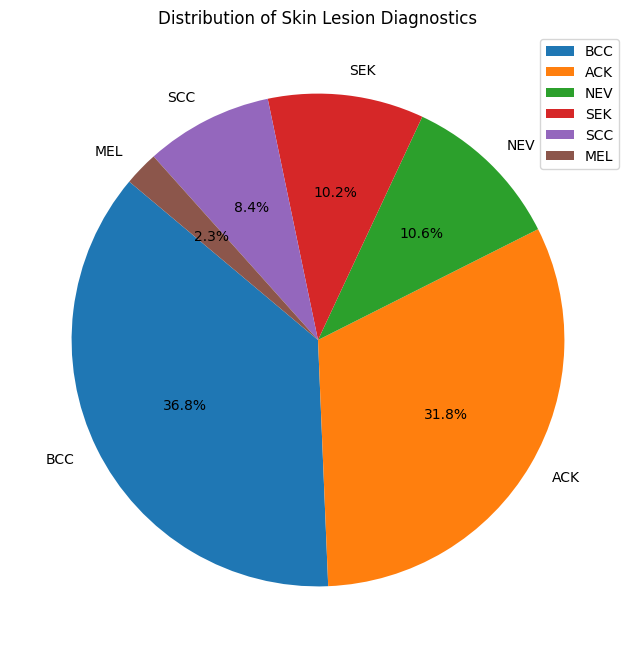

Raw Counts:
 diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64


In [ ]:
# 3. Target Distribution
diagnostic_counts = df['diagnostic'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(diagnostic_counts, labels=diagnostic_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Skin Lesion Diagnostics")
plt.legend(loc="best")
plt.show()

print("Raw Counts:\n", diagnostic_counts)

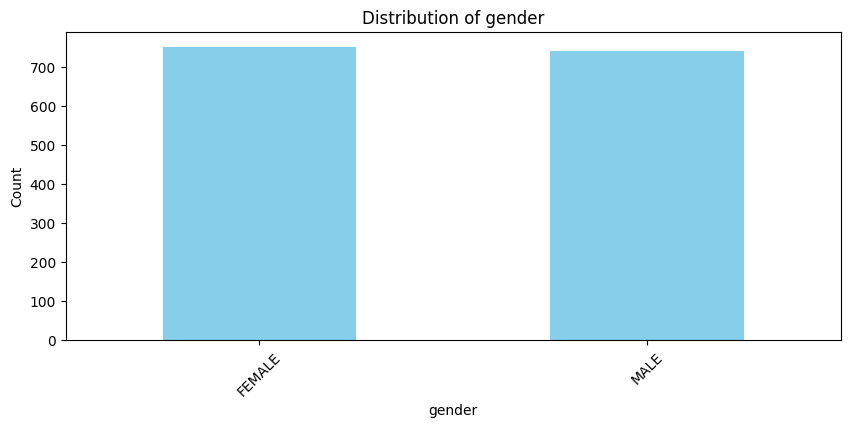

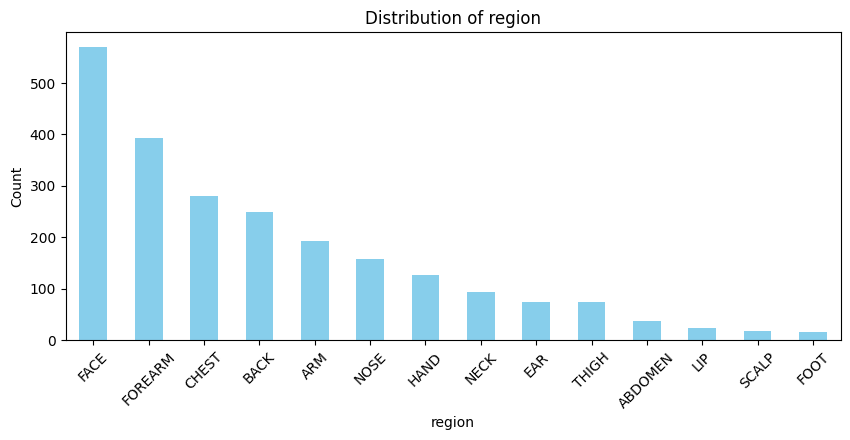

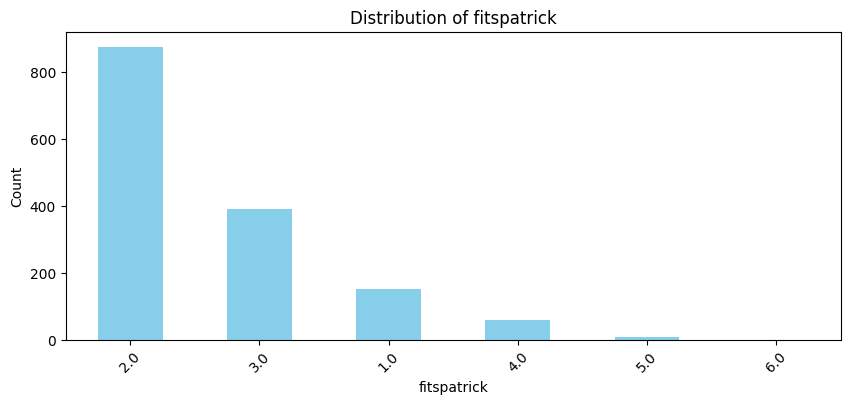

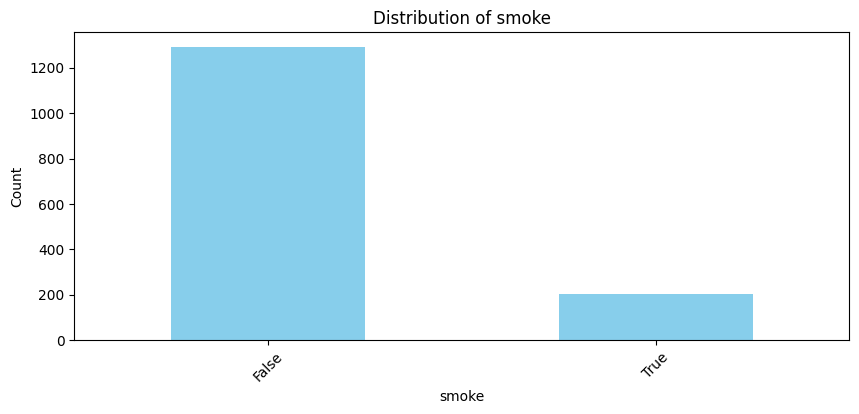

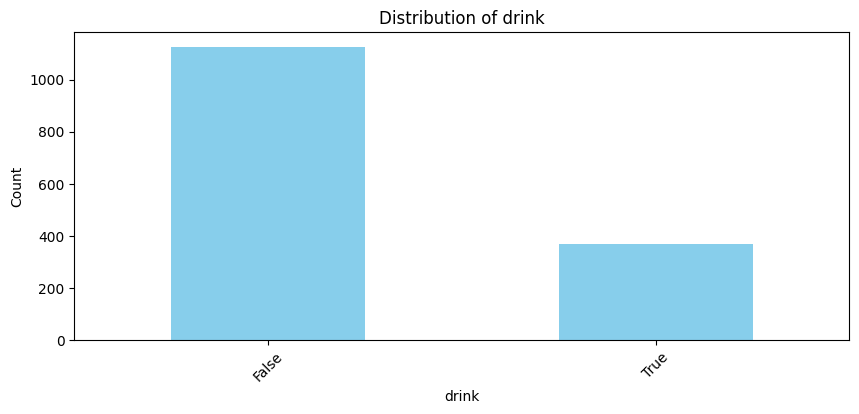

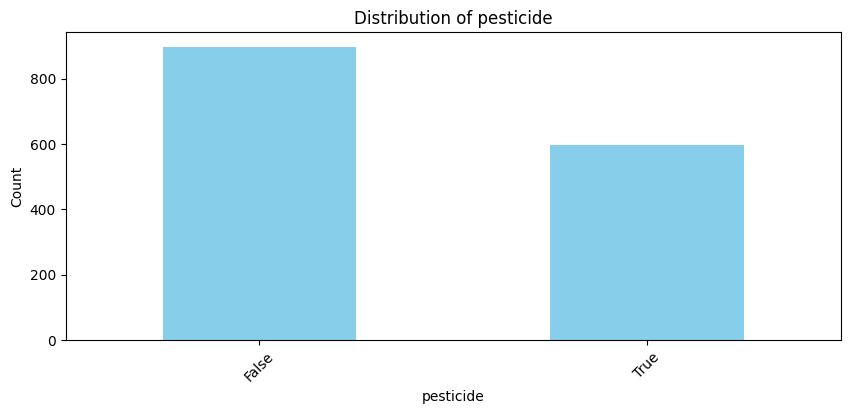

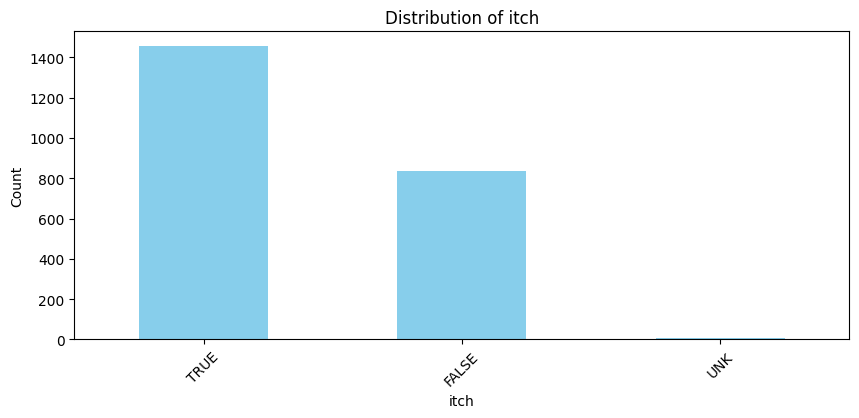

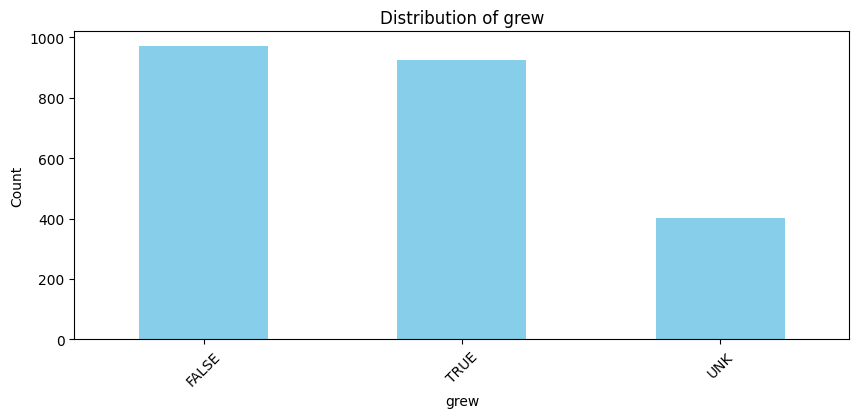

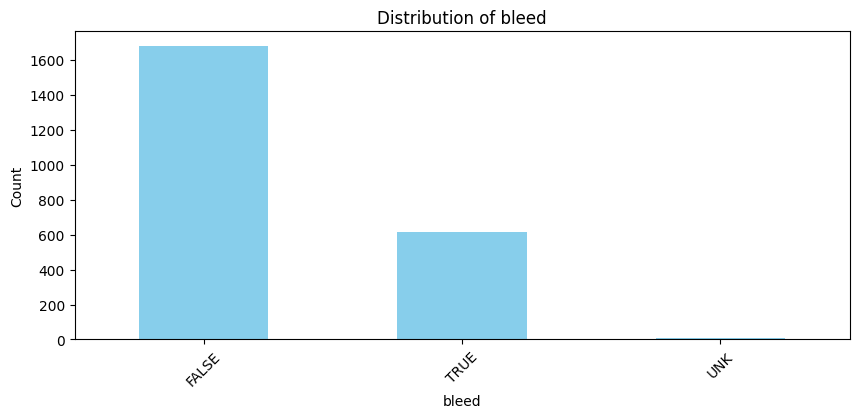

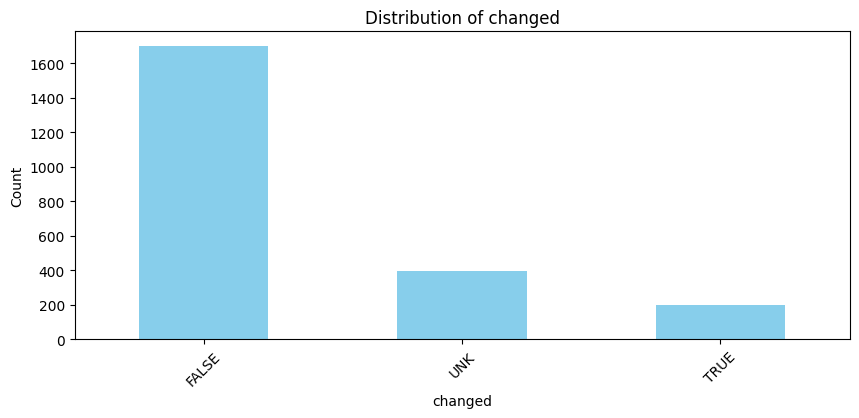

In [ ]:
# 4. Categorizing Columns
# Identifying which are categorical for bar plots and which are numerical for correlation
cat_cols = ['gender', 'region', 'fitspatrick', 'smoke', 'drink', 'pesticide', 'itch', 'grew', 'bleed', 'changed']
num_cols = ['age', 'diameter_1', 'diameter_2']

# Plotting categorical features
def _bar_plot(df, feature):
    plt.figure(figsize=(10, 4))
    df[feature].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

for col in cat_cols:
    _bar_plot(df, col)

In [ ]:
# 5. Relationship Testing
# Chi-Squared test

def chisquared_test(df: pd.DataFrame, col1: str, col2: str, alpha: float = 0.95):
    cross_table = pd.crosstab(df[col1], df[col2])
    val = stats.chi2_contingency(cross_table)
    chi2 = val[0]
    ddof = val[2]
    critical_value = stats.chi2.ppf(q=alpha, df=ddof)

    print(f'Testing relationship between {col1} and {col2}:')
    if chi2 >= critical_value:
        print(f'-> Reject H0: There is a significant relationship.')
    else:
        print(f'-> Retain H0: No significant relationship found.')
    print("----------------------------")

# Let's test a few clinical assumptions
for col in ['gender', 'smoke', 'itch', 'region']:
    chisquared_test(df, 'diagnostic', col)

Testing relationship between diagnostic and gender:
-> Reject H0: There is a significant relationship.
----------------------------
Testing relationship between diagnostic and smoke:
-> Reject H0: There is a significant relationship.
----------------------------
Testing relationship between diagnostic and itch:
-> Reject H0: There is a significant relationship.
----------------------------
Testing relationship between diagnostic and region:
-> Reject H0: There is a significant relationship.
----------------------------


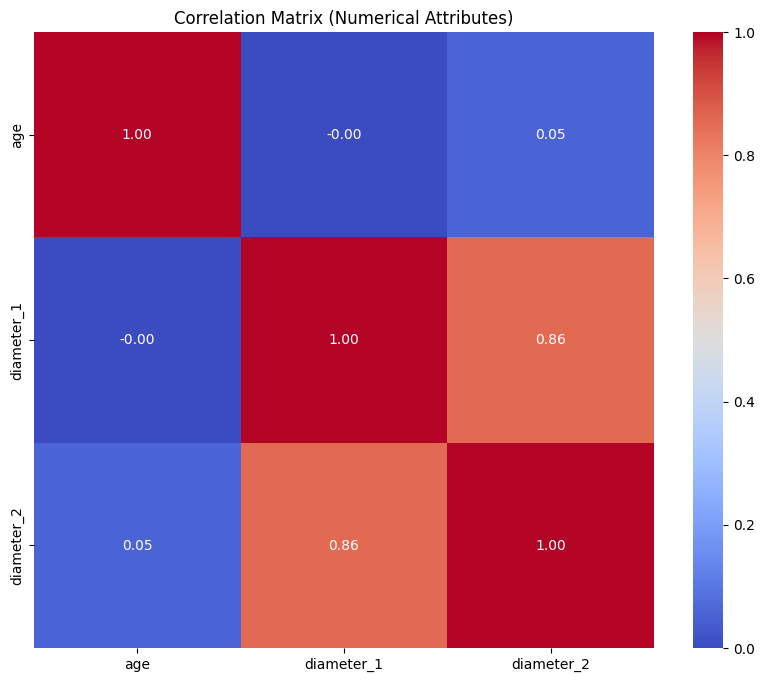

In [ ]:
# 6. Numerical Correlations
# Looking at how age and lesion size relate to each other
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Numerical Attributes)")
plt.show()